# Cricbuzz Cricket Player Performance Analysis



## Introduction

Cricket generates a large amount of player performance data across different formats, countries, and playing roles. Analyzing this data can help identify patterns in player performance, understand differences across player groups, and uncover meaningful relationships between different performance metrics.

In this project, we perform an end-to-end Exploratory Data Analysis (EDA) on cricket player data collected from Cricbuzz.The dataset contains information about 532 players across 79 attributes, covering player details, playing roles, batting and bowling styles, and performance statistics across formats such as Test, ODI, T20, and IPL.The analysis focuses on understanding the structure and quality of the dataset, cleaning and preparing the data, exploring individual variables, identifying relationships between variables, and analyzing multiple variables together.

The project uses Python-based data analysis and visualization techniques to answer predefined business questions and derive meaningful, data-driven insights from the dataset.


### Tools & Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn

### Key Areas of Analysis

* Data Understanding
* Data Quality Assessment
* Data Cleaning
* Univariate Analysis
* Bivariate Analysis
* Multivariate Analysis
* Statistical Analysis
* Data Visualization
* Business Insights



### Business Problem

Cricket performance data contains a wide range of player-level statistics across different playing roles, countries, and formats such as Test, ODI, and T20. However, these raw statistics are often presented as isolated metrics, making it difficult to identify meaningful performance patterns, compare players across different contexts, and understand how performance varies across roles, countries, and formats.

#### Business Objective
The objective of this project is to analyze Cricbuzz player data to identify meaningful patterns in player characteristics and performance across different cricket formats, playing roles, and countries.

##### Business Questions

* How are players distributed across different countries and playing roles?
* How does player participation vary across Test, ODI, T20, and IPL formats?
* What is the age distribution of players in the dataset?
* What are the distributions and characteristics of key batting performance metrics such as runs across different formats
* What are the distributions and characteristics of key batting performance metrics such as Economy across different formats
* What is the relationship between Age and strike rate across different cricket formats?
* What is the relationship between Average and strike rate across different cricket formats?
* How does the distribution of batting runs vary across different playing roles?
* How does wicket-taking performance vary across different playing roles?
* How does batting style distribution vary across different countries?
* How does the distribution of batting styles vary across different bowling styles?
* How do multiple batting and bowling performance metrics collectively reveal different player-performance patterns?
* How do multiple batting performance metrics vary across different batting styles?
* How do multiple bowling performance metrics collectively reveal different bowling-performance patterns?

##### importing libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Loading dataset

In [12]:
cric_data = pd.read_csv("cricbuzz_data_new.csv")

In [14]:
pd.set_option('display.max_columns',None)

In [16]:
cric_data.head()

,Unnamed: 0,Name,Country,Age,Role,Batting style,Bowling style,Test Matches,ODI Matches,T20 Matches,Ipl Matches,Test Innings,ODI Innings,T20 Innings,IPL Innings,Test Runs,ODI Runs,T20 Runs,IPL Runs,Test Balls,ODI Balls,T20 Balls,IPL Balls,Test Highest,ODI Highest,T20 Highest,IPL Highest,Test Average,ODI Average,T20 Average,IPL Average,Test Strikerate,ODI Strikerate,T20 Strikerate,IPL Strikerate,Test Fours,ODI Fours,T20 Fours,IPL Fours,Test Sixes,ODI Sixes,T20 Sixes,IPL Sixes,Test Ducks,ODI Ducks,T20 Ducks,IPL Ducks,Test 50s,ODI 50S,T20 50s,IPL 50s,Test 100s,ODI 100s,T20 100s,IPL 100s,Test 200s,ODI 200s,T20 200s,IPL 200s,Test bowl balls,Test bowl runs,Test Maidens,Test Wickets,Test Economy,ODI bowl balls,ODI bowl runs,ODI Maidens,ODI Wickets,ODI Economy,T20 bowl balls,T20 bowl runs,T20 Maidens,T20 Wickets,T20 Economy,IPL bowl balls,IPL bowl runs,IPL Maidens,IPL Wickets,IPL Economy
0,0,Virat Kohli,India,37,Batsman,Right Handed Bat,Right-arm medium,123.0,314.0,125.0,283.0,210.0,302.0,117.0,275.0,9230.0,14941.0,4188.0,9336.0,16608.0,15903.0,3056.0,6926.0,254.0,183.0,122.0,113.0,46.85,58.59,48.70,40.42,55.58,93.96,137.05,134.80,1027.0,1389.0,369.0,844.0,30.0,172.0,124.0,316.0,15.0,18.0,7.0,12.0,31.0,79.0,38.0,68.0,30.0,54.0,1.0,9.0,7.0,0.0,0.0,0.0,175.0,84.0,2.0,0.0,2.88,662.0,680.0,1.0,5.0,6.16,152.0,204.0,0.0,4.0,8.05,251.0,368.0,0.0,4.0,8.80
1,1,Rohit Sharma,India,39,Batsman,Right Handed Bat,Right-arm offbreak,67.0,288.0,159.0,281.0,116.0,280.0,151.0,276.0,4301.0,11895.0,4231.0,7329.0,7538.0,12784.0,3003.0,5514.0,212.0,264.0,121.0,109.0,40.58,48.95,31.34,29.79,57.06,93.05,140.90,132.92,473.0,1125.0,383.0,661.0,88.0,369.0,205.0,323.0,6.0,16.0,12.0,19.0,18.0,62.0,32.0,49.0,12.0,34.0,5.0,2.0,1.0,3.0,0.0,0.0,383.0,224.0,5.0,2.0,3.51,610.0,533.0,2.0,9.0,5.24,68.0,113.0,0.0,1.0,9.97,339.0,453.0,0.0,15.0,8.02
2,2,Shikhar Dhawan,India,40,Batsman,Left Handed Bat,Right-arm offbreak,34.0,167.0,68.0,222.0,58.0,164.0,66.0,221.0,2315.0,6793.0,1759.0,6768.0,3458.0,7436.0,1392.0,5324.0,190.0,143.0,92.0,106.0,40.61,44.11,27.92,35.07,66.95,91.36,126.37,127.13,316.0,842.0,191.0,768.0,12.0,79.0,50.0,152.0,4.0,5.0,2.0,12.0,5.0,39.0,11.0,51.0,7.0,17.0,0.0,2.0,0.0,0.0,0.0,0.0,54.0,18.0,2.0,0.0,2.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,48.0,66.0,0.0,4.0,8.25
3,3,Shubman Gill,India,27,Batsman,Right Handed Bat,Right-arm offbreak,43.0,67.0,36.0,134.0,77.0,66.0,36.0,131.0,3043.0,3379.0,869.0,4598.0,4956.0,3347.0,627.0,3236.0,269.0,208.0,126.0,129.0,42.86,59.28,28.03,40.33,61.41,100.96,138.60,142.09,342.0,395.0,98.0,446.0,47.0,69.0,26.0,152.0,5.0,1.0,2.0,4.0,9.0,20.0,3.0,32.0,11.0,9.0,1.0,5.0,1.0,1.0,0.0,0.0,19.0,9.0,0.0,0.0,2.84,18.0,25.0,0.0,0.0,8.33,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00
4,4,Shreyas Iyer,India,31,Batsman,Right Handed Bat,Right-arm legbreak,14.0,82.0,62.0,146.0,24.0,76.0,58.0,145.0,811.0,3136.0,1423.0,4229.0,1287.0,3205.0,1030.0,3093.0,105.0,128.0,80.0,101.0,36.86,45.45,32.34,35.84,63.02,97.85,138.16,136.73,94.0,283.0,120.0,353.0,16.0,78.0,51.0,182.0,2.0,2.0,4.0,7.0,5.0,24.0,10.0,32.0,1.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,2.0,0.0,0.0,2.00,37.0,39.0,0.0,0.0,6.32,2.0,2.0,0.0,0.0,0.00,6.0,7.0,0.0,0.0,7.00


#### Data Inspection

In [19]:
cric_data.shape

(532, 79)

In [21]:
cric_data.columns

Index(['Unnamed: 0', 'Name', 'Country', 'Age', 'Role', 'Batting style',
       'Bowling style', 'Test Matches', 'ODI Matches', 'T20 Matches',
       'Ipl Matches', 'Test Innings', 'ODI Innings', 'T20 Innings',
       'IPL Innings', 'Test Runs', 'ODI Runs', 'T20 Runs', 'IPL Runs',
       'Test Balls', 'ODI Balls', 'T20 Balls', 'IPL Balls', 'Test Highest',
       'ODI Highest', 'T20 Highest', 'IPL Highest', 'Test Average',
       'ODI Average', 'T20 Average', 'IPL Average', 'Test Strikerate',
       'ODI Strikerate', 'T20 Strikerate', 'IPL Strikerate', 'Test Fours',
       'ODI Fours', 'T20 Fours', 'IPL Fours', 'Test Sixes', 'ODI Sixes',
       'T20 Sixes', 'IPL Sixes', 'Test Ducks', 'ODI Ducks', 'T20 Ducks',
       'IPL Ducks', 'Test 50s', 'ODI 50S', 'T20 50s', 'IPL 50s', 'Test 100s',
       'ODI 100s', 'T20 100s', 'IPL 100s', 'Test 200s', 'ODI 200s', 'T20 200s',
       'IPL 200s', 'Test bowl balls', 'Test bowl runs', 'Test Maidens',
       'Test Wickets', 'Test Economy', 'ODI bowl ball

In [23]:
cric_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 79 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       532 non-null    int64  
 1   Name             532 non-null    object 
 2   Country          532 non-null    object 
 3   Age              532 non-null    int64  
 4   Role             532 non-null    object 
 5   Batting style    532 non-null    object 
 6   Bowling style    458 non-null    object 
 7   Test Matches     530 non-null    float64
 8   ODI Matches      530 non-null    float64
 9   T20 Matches      530 non-null    float64
 10  Ipl Matches      530 non-null    float64
 11  Test Innings     530 non-null    float64
 12  ODI Innings      530 non-null    float64
 13  T20 Innings      530 non-null    float64
 14  IPL Innings      530 non-null    float64
 15  Test Runs        530 non-null    float64
 16  ODI Runs         530 non-null    float64
 17  T20 Runs        

In [25]:
cric_data.describe()

,Unnamed: 0,Age,Test Matches,ODI Matches,T20 Matches,Ipl Matches,Test Innings,ODI Innings,T20 Innings,IPL Innings,Test Runs,ODI Runs,T20 Runs,IPL Runs,Test Balls,ODI Balls,T20 Balls,IPL Balls,Test Highest,ODI Highest,T20 Highest,IPL Highest,Test Average,ODI Average,T20 Average,IPL Average,Test Strikerate,ODI Strikerate,T20 Strikerate,IPL Strikerate,Test Fours,ODI Fours,T20 Fours,IPL Fours,Test Sixes,ODI Sixes,T20 Sixes,IPL Sixes,Test Ducks,ODI Ducks,T20 Ducks,IPL Ducks,Test 50s,ODI 50S,T20 50s,IPL 50s,Test 100s,ODI 100s,T20 100s,IPL 100s,Test 200s,ODI 200s,T20 200s,IPL 200s,Test bowl balls,Test bowl runs,Test Maidens,Test Wickets,Test Economy,ODI bowl balls,ODI bowl runs,ODI Maidens,ODI Wickets,ODI Economy,T20 bowl balls,T20 bowl runs,T20 Maidens,T20 Wickets,T20 Economy,IPL bowl balls,IPL bowl runs,IPL Maidens,IPL Wickets,IPL Economy
count,532.000000,532.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.00000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.0,530.0,530.000000,530.000000,530.000000,530.00000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000
mean,265.500000,35.127820,15.907547,52.081132,44.149057,19.758491,26.926415,42.873585,33.188679,14.771698,755.567925,1107.528302,630.843396,340.801887,1399.264151,1319.847170,489.200000,246.286792,53.907547,68.777358,46.616981,17.601887,13.011094,21.097377,16.191189,6.377132,27.655792,71.515000,100.30083,40.513698,87.113208,101.198113,54.009434,30.230189,7.220755,21.932075,25.243396,14.841509,2.735849,3.428302,2.813208,1.016981,3.520755,5.900000,3.079245,1.960377,1.492453,1.666038,0.194340,0.154717,0.139623,0.016981,0.0,0.0,1318.007547,698.886792,40.756604,22.69434,1.452962,1187.003774,1027.456604,8.458491,31.435849,3.968151,422.920755,539.788679,0.818868,22.996226,5.152642,183.364151,257.056604,0.190566,9.050943,2.417264
std,153.719441,6.188396,27.607650,57.545076,38.829452,45.584486,46.905289,52.135902,33.970273,38.423503,1691.527781,1857.010874,859.329507,1065.935827,3104.612582,2158.933693,639.680545,775.840166,75.826566,53.668233,38.864343,34.505773,15.624858,14.300755,11.463031,11.377084,28.445632,28.990846,45.91408,62.276387,193.648207,175.799821,78.610246,98.880347,15.842990,38.510734,37.242870,45.182903,4.724352,4.055330,2.931643,2.648553,8.262960,10.902533,5.656298,7.284415,4.440846,4.556698,0.625518,0.784193,0.644400,0.167531,0.0,0.0,3661.868990,1866.468122,122.525531,66.11519,1.859723,1890.560649,1592.969201,15.942927,51.692568,2.717693,626.467609,787.018196,1.898468,35.703568,4.058296,591.875486,796.745896,0.882248,29.529506,4.332317
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,132.750000,31.000000,0.000000,10.000000,10.000000,0.000000,0.000000,7.000000,6.000000,0.000000,0.000000,63.250000,25.000000,0.000000,0.000000,101.750000,29.250000,0.000000,0.000000,23.000000,11.000000,0.000000,0.

In [27]:
cric_data.describe(include = 'object')

,Name,Country,Role,Batting style,Bowling style
count,532,532,532,532,458
unique,531,26,5,4,10
top,Nitish Kumar,India,Bowler,Right Handed Bat,Right-arm fast-medium
freq,2,36,153,340,117


##### Data Understanding

After inspecting the data, we have found that the dataset contains cricket player-level information collected from Cricbuzz. Each row represents an individual cricket player, while the columns contain information related to the player's profile, playing characteristics, format participation, and performance statistics.
The dataset contains 532 player records and 79 attributes covering different aspects of cricket player performance.

The dataset includes information related to:
* Player profile 
* Country and playing role
* Batting style
* Bowling style
* Participation across different cricket formats
* Batting performance
* Bowling 

The dataset contains player statistics across:

* Test
* ODI
* T20
* IPL

The dataset includes various batting and bowling performance indicators, such as:

* Matches played
* Innings
* Runs
* Highest score
* Batting average
* Strike rate
* Fours and sixes
* Ducks
* Half-centuries and centuries
* Wickets
* Bowling average
* Economy rate
* Bowling strike rate
* Maidens

#### Data Quality Assessment

In [32]:
pd.set_option('display.max_rows',None)

In [34]:
cric_data.isna().sum()

Unnamed: 0          0
Name                0
Country             0
Age                 0
Role                0
Batting style       0
Bowling style      74
Test Matches        2
ODI Matches         2
T20 Matches         2
Ipl Matches         2
Test Innings        2
ODI Innings         2
T20 Innings         2
IPL Innings         2
Test Runs           2
ODI Runs            2
T20 Runs            2
IPL Runs            2
Test Balls          2
ODI Balls           2
T20 Balls           2
IPL Balls           2
Test Highest        2
ODI Highest         2
T20 Highest         2
IPL Highest         2
Test Average        2
ODI Average         2
T20 Average         2
IPL Average         2
Test Strikerate     2
ODI Strikerate      2
T20 Strikerate      2
IPL Strikerate      2
Test Fours          2
ODI Fours           2
T20 Fours           2
IPL Fours           2
Test Sixes          2
ODI Sixes           2
T20 Sixes           2
IPL Sixes           2
Test Ducks          2
ODI Ducks           2
T20 Ducks 

In [36]:
cric_data.duplicated().sum()

0

In [38]:
cric_data.dtypes

Unnamed: 0           int64
Name                object
Country             object
Age                  int64
Role                object
Batting style       object
Bowling style       object
Test Matches       float64
ODI Matches        float64
T20 Matches        float64
Ipl Matches        float64
Test Innings       float64
ODI Innings        float64
T20 Innings        float64
IPL Innings        float64
Test Runs          float64
ODI Runs           float64
T20 Runs           float64
IPL Runs           float64
Test Balls         float64
ODI Balls          float64
T20 Balls          float64
IPL Balls          float64
Test Highest       float64
ODI Highest        float64
T20 Highest        float64
IPL Highest        float64
Test Average       float64
ODI Average        float64
T20 Average        float64
IPL Average        float64
Test Strikerate    float64
ODI Strikerate     float64
T20 Strikerate     float64
IPL Strikerate     float64
Test Fours         float64
ODI Fours          float64
T

Take away:
* The dataset contains missing values mainly in Bowling style and format-specific performance columns
* The dataset contains no duplicate records.
* Most data types are appropriate, while performance columns require further assessment due to missing values

#### Data Cleaning

In [42]:
cric_data = cric_data.drop(columns = 'Unnamed: 0')

In [44]:
cric_data.head()

,Name,Country,Age,Role,Batting style,Bowling style,Test Matches,ODI Matches,T20 Matches,Ipl Matches,Test Innings,ODI Innings,T20 Innings,IPL Innings,Test Runs,ODI Runs,T20 Runs,IPL Runs,Test Balls,ODI Balls,T20 Balls,IPL Balls,Test Highest,ODI Highest,T20 Highest,IPL Highest,Test Average,ODI Average,T20 Average,IPL Average,Test Strikerate,ODI Strikerate,T20 Strikerate,IPL Strikerate,Test Fours,ODI Fours,T20 Fours,IPL Fours,Test Sixes,ODI Sixes,T20 Sixes,IPL Sixes,Test Ducks,ODI Ducks,T20 Ducks,IPL Ducks,Test 50s,ODI 50S,T20 50s,IPL 50s,Test 100s,ODI 100s,T20 100s,IPL 100s,Test 200s,ODI 200s,T20 200s,IPL 200s,Test bowl balls,Test bowl runs,Test Maidens,Test Wickets,Test Economy,ODI bowl balls,ODI bowl runs,ODI Maidens,ODI Wickets,ODI Economy,T20 bowl balls,T20 bowl runs,T20 Maidens,T20 Wickets,T20 Economy,IPL bowl balls,IPL bowl runs,IPL Maidens,IPL Wickets,IPL Economy
0,Virat Kohli,India,37,Batsman,Right Handed Bat,Right-arm medium,123.0,314.0,125.0,283.0,210.0,302.0,117.0,275.0,9230.0,14941.0,4188.0,9336.0,16608.0,15903.0,3056.0,6926.0,254.0,183.0,122.0,113.0,46.85,58.59,48.70,40.42,55.58,93.96,137.05,134.80,1027.0,1389.0,369.0,844.0,30.0,172.0,124.0,316.0,15.0,18.0,7.0,12.0,31.0,79.0,38.0,68.0,30.0,54.0,1.0,9.0,7.0,0.0,0.0,0.0,175.0,84.0,2.0,0.0,2.88,662.0,680.0,1.0,5.0,6.16,152.0,204.0,0.0,4.0,8.05,251.0,368.0,0.0,4.0,8.80
1,Rohit Sharma,India,39,Batsman,Right Handed Bat,Right-arm offbreak,67.0,288.0,159.0,281.0,116.0,280.0,151.0,276.0,4301.0,11895.0,4231.0,7329.0,7538.0,12784.0,3003.0,5514.0,212.0,264.0,121.0,109.0,40.58,48.95,31.34,29.79,57.06,93.05,140.90,132.92,473.0,1125.0,383.0,661.0,88.0,369.0,205.0,323.0,6.0,16.0,12.0,19.0,18.0,62.0,32.0,49.0,12.0,34.0,5.0,2.0,1.0,3.0,0.0,0.0,383.0,224.0,5.0,2.0,3.51,610.0,533.0,2.0,9.0,5.24,68.0,113.0,0.0,1.0,9.97,339.0,453.0,0.0,15.0,8.02
2,Shikhar Dhawan,India,40,Batsman,Left Handed Bat,Right-arm offbreak,34.0,167.0,68.0,222.0,58.0,164.0,66.0,221.0,2315.0,6793.0,1759.0,6768.0,3458.0,7436.0,1392.0,5324.0,190.0,143.0,92.0,106.0,40.61,44.11,27.92,35.07,66.95,91.36,126.37,127.13,316.0,842.0,191.0,768.0,12.0,79.0,50.0,152.0,4.0,5.0,2.0,12.0,5.0,39.0,11.0,51.0,7.0,17.0,0.0,2.0,0.0,0.0,0.0,0.0,54.0,18.0,2.0,0.0,2.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,48.0,66.0,0.0,4.0,8.25
3,Shubman Gill,India,27,Batsman,Right Handed Bat,Right-arm offbreak,43.0,67.0,36.0,134.0,77.0,66.0,36.0,131.0,3043.0,3379.0,869.0,4598.0,4956.0,3347.0,627.0,3236.0,269.0,208.0,126.0,129.0,42.86,59.28,28.03,40.33,61.41,100.96,138.60,142.09,342.0,395.0,98.0,446.0,47.0,69.0,26.0,152.0,5.0,1.0,2.0,4.0,9.0,20.0,3.0,32.0,11.0,9.0,1.0,5.0,1.0,1.0,0.0,0.0,19.0,9.0,0.0,0.0,2.84,18.0,25.0,0.0,0.0,8.33,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00
4,Shreyas Iyer,India,31,Batsman,Right Handed Bat,Right-arm legbreak,14.0,82.0,62.0,146.0,24.0,76.0,58.0,145.0,811.0,3136.0,1423.0,4229.0,1287.0,3205.0,1030.0,3093.0,105.0,128.0,80.0,101.0,36.86,45.45,32.34,35.84,63.02,97.85,138.16,136.73,94.0,283.0,120.0,353.0,16.0,78.0,51.0,182.0,2.0,2.0,4.0,7.0,5.0,24.0,10.0,32.0,1.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,2.0,0.0,0.0,2.00,37.0,39.0,0.0,0.0,6.32,2.0,2.0,0.0,0.0,0.00,6.0,7.0,0.0,0.0,7.00


In [46]:
cric_data[cric_data['Test Matches'].isna()] #misiing values handling

,Name,Country,Age,Role,Batting style,Bowling style,Test Matches,ODI Matches,T20 Matches,Ipl Matches,Test Innings,ODI Innings,T20 Innings,IPL Innings,Test Runs,ODI Runs,T20 Runs,IPL Runs,Test Balls,ODI Balls,T20 Balls,IPL Balls,Test Highest,ODI Highest,T20 Highest,IPL Highest,Test Average,ODI Average,T20 Average,IPL Average,Test Strikerate,ODI Strikerate,T20 Strikerate,IPL Strikerate,Test Fours,ODI Fours,T20 Fours,IPL Fours,Test Sixes,ODI Sixes,T20 Sixes,IPL Sixes,Test Ducks,ODI Ducks,T20 Ducks,IPL Ducks,Test 50s,ODI 50S,T20 50s,IPL 50s,Test 100s,ODI 100s,T20 100s,IPL 100s,Test 200s,ODI 200s,T20 200s,IPL 200s,Test bowl balls,Test bowl runs,Test Maidens,Test Wickets,Test Economy,ODI bowl balls,ODI bowl runs,ODI Maidens,ODI Wickets,ODI Economy,T20 bowl balls,T20 bowl runs,T20 Maidens,T20 Wickets,T20 Economy,IPL bowl balls,IPL bowl runs,IPL Maidens,IPL Wickets,IPL Economy
430,Twinkal Bhandari,Oman,38,WK-Batsman,Right Handed Bat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
481,Ibrahim Akello,Kenya,41,Bowler,Right Handed Bat,Right-arm fast-medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
cric_data.dropna(subset = ['Test Matches'],inplace=True)

In [50]:
cric_data.groupby('Role')['Bowling style'].apply(lambda x: x.isna().sum())

Role
Batsman                21
Batting Allrounder      0
Bowler                  0
Bowling Allrounder      0
WK-Batsman             52
Name: Bowling style, dtype: int64

In [52]:
cric_data['Bowling style'] = cric_data['Bowling style'].fillna('Unknown')

In [54]:
cric_data.isna().any().sum()

0

Handling misiing values take away:

1. Two player records with completely unavailable performance statistics were removed rather than imputing artificial values.
2. Missing Bowling style values require role-based treatment because the missing value may be meaningful for players who do not bowl.After finding out those missing values are belong to players who do not bowl impute 'unknown' rather than mode for better analysis.

In [57]:
# Handling outliers
numeric_columns = cric_data.select_dtypes(include='number').columns
q1 = cric_data[numeric_columns].quantile(0.25)
q3 = cric_data[numeric_columns].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR
outlier_count = ((cric_data[numeric_columns] < lower_bound) | (cric_data[numeric_columns] > upper_bound)).sum()

In [59]:
# potential outliers
outlier_count.sort_values(ascending = False)

IPL bowl runs      126
IPL bowl balls     124
Test 100s          123
IPL Fours          121
IPL Ducks          120
IPL Runs           117
IPL Wickets        117
IPL Balls          116
IPL Sixes          114
Test Maidens       107
Test bowl balls    104
Test Wickets       103
Test bowl runs     102
Ipl Matches         99
IPL Highest         97
IPL Innings         97
Test 50s            93
ODI 100s            86
IPL 50s             84
Test Balls          81
Test Runs           81
Test Fours          79
Test Sixes          74
IPL Average         73
ODI 50S             68
Test Innings        66
T20 100s            64
T20 Maidens         61
ODI Maidens         61
Test Matches        61
T20 Strikerate      58
ODI Sixes           57
T20 50s             55
ODI Fours           54
ODI Balls           54
ODI Runs            52
ODI Wickets         51
ODI bowl balls      49
ODI bowl runs       49
Test Ducks          47
IPL Maidens         44
T20 Wickets         44
ODI Innings         44
T20 Runs   

In [61]:
cric_data[['Name', 'IPL Runs']].sort_values(by='IPL Runs',ascending=False).head(10)

,Name,IPL Runs
0,Virat Kohli,9336.0
1,Rohit Sharma,7329.0
2,Shikhar Dhawan,6768.0
38,David Warner,6565.0
16,KL Rahul,5815.0
9,Ajinkya Rahane,5367.0
17,Sanju Samson,5181.0
269,Chris Gayle,4965.0
99,Faf du,4773.0
79,Jos Buttler,4646.0


In [63]:
cric_data[['Name', 'Test Runs']].sort_values(by='Test Runs',ascending=False).head(10)

,Name,Test Runs
68,Joe Root,14278.0
37,Steven Smith,10920.0
129,Kane Williamson,9515.0
0,Virat Kohli,9230.0
38,David Warner,8786.0
214,Angelo Mathews,8214.0
128,Ross Taylor,7684.0
72,Ben Stokes,7273.0
212,Dimuth Karunaratne,7222.0
269,Chris Gayle,7215.0


outlier handling take away:

Potential outliers were identified using the IQR method. However, these extreme values represent genuine player performance and are not data-quality errors. Therefore, the values were retained without removal or capping to preserve the integrity of the analysis.

In [66]:
# Handling categorical string data

In [68]:
categorical_columns = cric_data.select_dtypes('object').columns
categorical_columns

Index(['Name', 'Country', 'Role', 'Batting style', 'Bowling style'], dtype='object')

In [70]:
for col in categorical_columns:
    print(f'\n {col} :')
    print(cric_data[col].unique())



 Name :
['Virat Kohli' 'Rohit Sharma' 'Shikhar Dhawan' 'Shubman Gill'
 'Shreyas Iyer' 'Manish Pandey' 'Mayank Agarwal' 'Prithvi Shaw'
 'Cheteshwar Pujara' 'Ajinkya Rahane' 'Ruturaj Gaikwad' 'Hardik Pandya'
 'Hanuma Vihari' 'Ravindra Jadeja' 'Shardul Thakur' 'Ravichandran Ashwin'
 'KL Rahul' 'Sanju Samson' 'Wriddhiman Saha' 'Rishabh Pant'
 'Mohammed Shami' 'Jasprit Bumrah' 'Kuldeep Yadav' 'Yuzvendra Chahal'
 'Navdeep Saini' 'Umesh Yadav' 'Mohammed Siraj' 'Suryakumar Yadav'
 'Nitish Kumar' 'Arshdeep Singh' 'Shivam Dube' 'Abhishek Sharma'
 'Yashasvi Jaiswal' 'Axar Patel' 'Rinku Singh' 'Washington Sundar'
 'Aaron Finch' 'Steven Smith' 'David Warner' 'Marnus Labuschagne'
 'Joe Burns' 'Will Pucovski' 'Travis Head' 'Glenn Maxwell'
 'Marcus Stoinis' 'Moises Henriques' 'Cameron Green' 'Ashton Agar'
 'Daniel Sams' 'Michael Neser' 'Alex Carey' 'Matthew Wade' 'Tim Paine'
 'Pat Cummins' 'Nathan Lyon' 'Mitchell Starc' 'Adam Zampa' 'Sean Abbott'
 'Josh Hazlewood' 'Andrew Tye' 'James Pattinson' 'Mitc

In [72]:
cric_data['Batting style'].unique()

array(['Right Handed Bat ', 'Left Handed Bat ', 'Right Handed Bat',
       'Left Handed Bat'], dtype=object)

In [74]:
cric_data['Batting style'] = cric_data['Batting style'].str.strip()

In [76]:
cric_data['Batting style'].value_counts()

Batting style
Right Handed Bat    396
Left Handed Bat     134
Name: count, dtype: int64

In [78]:
cric_data['Role'] = cric_data['Role'].str.strip()

In [80]:
cric_data['Role'].unique()

array(['Batsman', 'Batting Allrounder', 'Bowling Allrounder',
       'WK-Batsman', 'Bowler'], dtype=object)

String data handling take away: 

Categorical and string variables were inspected for inconsistent values and unwanted leading or trailing spaces. The identified inconsistencies were corrected while preserving the original meaningful category labels

In [83]:
# Handling Inappropriate data

In [85]:
cric_data.dtypes

Name                object
Country             object
Age                  int64
Role                object
Batting style       object
Bowling style       object
Test Matches       float64
ODI Matches        float64
T20 Matches        float64
Ipl Matches        float64
Test Innings       float64
ODI Innings        float64
T20 Innings        float64
IPL Innings        float64
Test Runs          float64
ODI Runs           float64
T20 Runs           float64
IPL Runs           float64
Test Balls         float64
ODI Balls          float64
T20 Balls          float64
IPL Balls          float64
Test Highest       float64
ODI Highest        float64
T20 Highest        float64
IPL Highest        float64
Test Average       float64
ODI Average        float64
T20 Average        float64
IPL Average        float64
Test Strikerate    float64
ODI Strikerate     float64
T20 Strikerate     float64
IPL Strikerate     float64
Test Fours         float64
ODI Fours          float64
T20 Fours          float64
I

In [87]:
cric_data.select_dtypes('number').columns

Index(['Age', 'Test Matches', 'ODI Matches', 'T20 Matches', 'Ipl Matches',
       'Test Innings', 'ODI Innings', 'T20 Innings', 'IPL Innings',
       'Test Runs', 'ODI Runs', 'T20 Runs', 'IPL Runs', 'Test Balls',
       'ODI Balls', 'T20 Balls', 'IPL Balls', 'Test Highest', 'ODI Highest',
       'T20 Highest', 'IPL Highest', 'Test Average', 'ODI Average',
       'T20 Average', 'IPL Average', 'Test Strikerate', 'ODI Strikerate',
       'T20 Strikerate', 'IPL Strikerate', 'Test Fours', 'ODI Fours',
       'T20 Fours', 'IPL Fours', 'Test Sixes', 'ODI Sixes', 'T20 Sixes',
       'IPL Sixes', 'Test Ducks', 'ODI Ducks', 'T20 Ducks', 'IPL Ducks',
       'Test 50s', 'ODI 50S', 'T20 50s', 'IPL 50s', 'Test 100s', 'ODI 100s',
       'T20 100s', 'IPL 100s', 'Test 200s', 'ODI 200s', 'T20 200s', 'IPL 200s',
       'Test bowl balls', 'Test bowl runs', 'Test Maidens', 'Test Wickets',
       'Test Economy', 'ODI bowl balls', 'ODI bowl runs', 'ODI Maidens',
       'ODI Wickets', 'ODI Economy', 'T20 bowl

In [89]:
#Numerical data columns dtype change

cric_data['Test Matches'] = cric_data['Test Matches'].astype('int64')
cric_data['ODI Matches'] = cric_data['ODI Matches'].astype('int64')
cric_data['T20 Matches'] = cric_data['T20 Matches'].astype('int64')
cric_data['Ipl Matches'] = cric_data['Ipl Matches'].astype('int64')
cric_data['Test Innings'] = cric_data['Test Innings'].astype('int64')
cric_data['ODI Innings'] = cric_data['ODI Innings'].astype('int64')
cric_data['T20 Innings'] = cric_data['T20 Innings'].astype('int64')
cric_data['IPL Innings'] = cric_data['IPL Innings'].astype('int64')
cric_data['Test Runs'] = cric_data['Test Runs'].astype('int64')
cric_data['ODI Runs'] = cric_data['ODI Runs'].astype('int64')
cric_data['T20 Runs'] = cric_data['T20 Runs'].astype('int64')
cric_data['IPL Runs'] = cric_data['IPL Runs'].astype('int64')
cric_data['Test Balls'] = cric_data['Test Balls'].astype('int64')
cric_data['ODI Balls'] = cric_data['ODI Balls'].astype('int64')
cric_data['T20 Balls'] = cric_data['T20 Balls'].astype('int64')
cric_data['IPL Balls'] = cric_data['IPL Balls'].astype('int64')
cric_data['Test Highest'] = cric_data['Test Highest'].astype('int64')
cric_data['ODI Highest'] = cric_data['ODI Highest'].astype('int64')
cric_data['T20 Highest'] = cric_data['T20 Highest'].astype('int64')
cric_data['IPL Highest'] = cric_data['IPL Highest'].astype('int64')
cric_data['Test Fours'] = cric_data['Test Fours'].astype('int64')
cric_data['ODI Fours'] = cric_data['ODI Fours'].astype('int64')
cric_data['T20 Fours'] = cric_data['T20 Fours'].astype('int64')
cric_data['IPL Fours'] = cric_data['IPL Fours'].astype('int64')
cric_data['Test Sixes'] = cric_data['Test Sixes'].astype('int64')
cric_data['ODI Sixes'] = cric_data['ODI Sixes'].astype('int64')
cric_data['T20 Sixes'] = cric_data['T20 Sixes'].astype('int64')
cric_data['IPL Sixes'] = cric_data['IPL Sixes'].astype('int64')
cric_data['Test Ducks'] = cric_data['Test Ducks'].astype('int64')
cric_data['ODI Ducks'] = cric_data['ODI Ducks'].astype('int64')
cric_data['T20 Ducks'] = cric_data['T20 Ducks'].astype('int64')
cric_data['IPL Ducks'] = cric_data['IPL Ducks'].astype('int64')
cric_data['Test 50s'] = cric_data['Test 50s'].astype('int64')
cric_data['ODI 50S'] = cric_data['ODI 50S'].astype('int64')
cric_data['T20 50s'] = cric_data['T20 50s'].astype('int64')
cric_data['IPL 50s'] = cric_data['IPL 50s'].astype('int64')
cric_data['Test 100s'] = cric_data['Test 100s'].astype('int64')
cric_data['ODI 100s'] = cric_data['ODI 100s'].astype('int64')
cric_data['T20 100s'] = cric_data['T20 100s'].astype('int64')
cric_data['IPL 100s'] = cric_data['IPL 100s'].astype('int64')
cric_data['Test 200s'] = cric_data['Test 200s'].astype('int64')
cric_data['ODI 200s'] = cric_data['ODI 200s'].astype('int64')
cric_data['T20 200s'] = cric_data['T20 200s'].astype('int64')
cric_data['IPL 200s'] = cric_data['IPL 200s'].astype('int64')


cric_data['Test bowl balls'] = cric_data['Test bowl balls'].astype('int64')
cric_data['ODI bowl balls'] = cric_data['ODI bowl balls'].astype('int64')
cric_data['T20 bowl balls'] = cric_data['T20 bowl balls'].astype('int64')
cric_data['IPL bowl balls'] = cric_data['IPL bowl balls'].astype('int64')
cric_data['Test bowl runs'] = cric_data['Test bowl runs'].astype('int64')
cric_data['ODI bowl runs'] = cric_data['ODI bowl runs'].astype('int64')
cric_data['T20 bowl runs'] = cric_data['T20 bowl runs'].astype('int64')
cric_data['IPL bowl runs'] = cric_data['IPL bowl runs'].astype('int64')
cric_data['Test Maidens'] = cric_data['Test Maidens'].astype('int64')
cric_data['ODI Maidens'] = cric_data['ODI Maidens'].astype('int64')
cric_data['T20 Maidens'] = cric_data['T20 Maidens'].astype('int64')
cric_data['IPL Maidens'] = cric_data['IPL Maidens'].astype('int64')
cric_data['Test Wickets'] = cric_data['Test Wickets'].astype('int64')
cric_data['ODI Wickets'] = cric_data['ODI Wickets'].astype('int64')
cric_data['T20 Wickets'] = cric_data['T20 Wickets'].astype('int64')
cric_data['IPL Wickets'] = cric_data['IPL Wickets'].astype('int64')

In [91]:
categorical_columns = cric_data.select_dtypes('object').columns
categorical_columns

Index(['Name', 'Country', 'Role', 'Batting style', 'Bowling style'], dtype='object')

In [93]:
# object type data dtype change
for col in categorical_columns:
    print(cric_data[col].nunique())

529
26
5
2
11


In [95]:
cric_data['Country'] = cric_data['Country'].astype('category')
cric_data['Role'] = cric_data['Role'].astype('category')
cric_data['Batting style'] = cric_data['Batting style'].astype('category')
cric_data['Bowling style'] = cric_data['Bowling style'].astype('category')

Appropriate data yypes take away:

The data types of all variables were reviewed and found to be appropriate for analysis. Numerical variables were retained in suitable numeric formats, while categorical and string variables were maintained as text data. No unnecessary data type conversions were performed.

In [98]:
cric_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530 entries, 0 to 531
Data columns (total 78 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Name             530 non-null    object  
 1   Country          530 non-null    category
 2   Age              530 non-null    int64   
 3   Role             530 non-null    category
 4   Batting style    530 non-null    category
 5   Bowling style    530 non-null    category
 6   Test Matches     530 non-null    int64   
 7   ODI Matches      530 non-null    int64   
 8   T20 Matches      530 non-null    int64   
 9   Ipl Matches      530 non-null    int64   
 10  Test Innings     530 non-null    int64   
 11  ODI Innings      530 non-null    int64   
 12  T20 Innings      530 non-null    int64   
 13  IPL Innings      530 non-null    int64   
 14  Test Runs        530 non-null    int64   
 15  ODI Runs         530 non-null    int64   
 16  T20 Runs         530 non-null    int64   
 17  IP

In [100]:
cric_data_clean = cric_data.copy()

In [102]:
# final cleaned dataset ready for analysis

In [104]:
# How are players distributed across countries

In [106]:
cric_data['Country'].value_counts()

Country
India                       36
England                     33
Sri Lanka                   31
Pakistan                    30
Australia                   29
New Zealand                 28
Netherlands                 28
Canada                      28
South Africa                28
Bangladesh                  27
West Indies                 27
Afghanistan                 26
Zimbabwe                    26
Ireland                     25
Kenya                       18
Papua New Guinea            18
Nepal                       16
Scotland                    16
United Arab Emirates        16
Namibia                     14
Oman                        13
Hong Kong, China            13
Portugal                     1
Samoa                        1
Italy                        1
United States of America     1
Name: count, dtype: int64

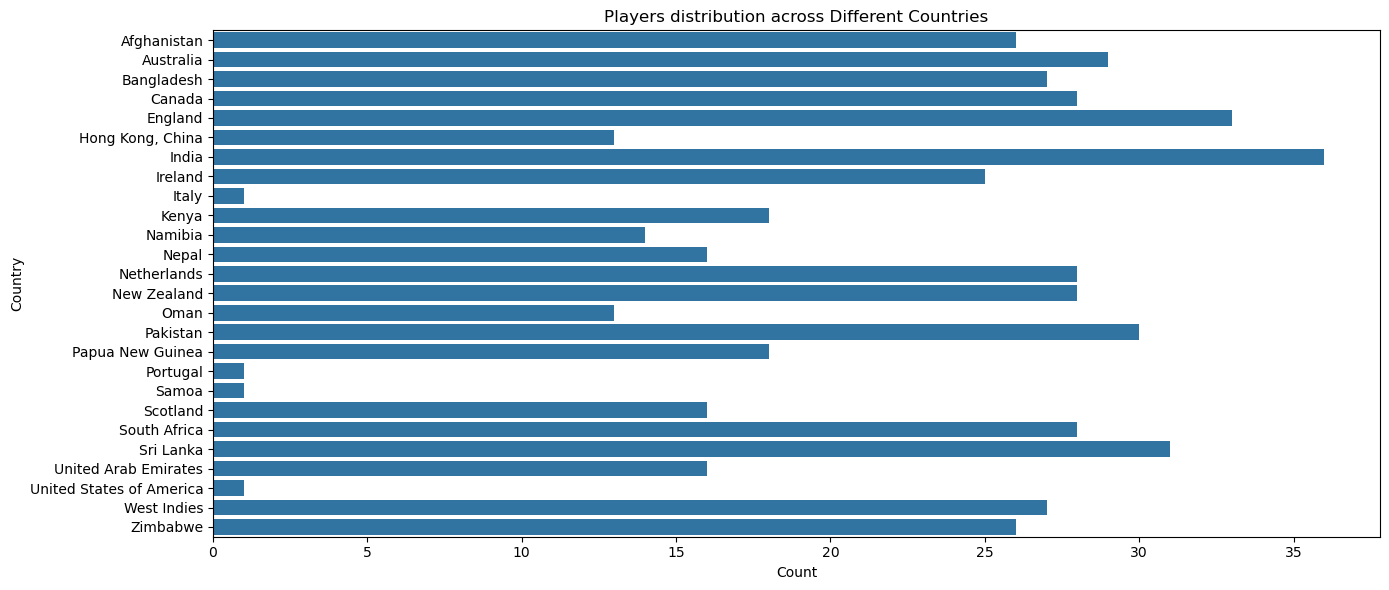

In [108]:
plt.figure(figsize  = (14,6))
sns.countplot(data = cric_data,y = 'Country')
plt.ylabel('Country')
plt.xlabel('Count')
plt.title('Players distribution across Different Countries')
plt.tight_layout()
plt.show()

Insight - The uneven representation of players across countries provides important context for comparing player performance. Country-level performance comparisons should consider differences in player representation, especially for countries with very small samples.

In [111]:
# How are players distributed across different playing roles

In [113]:
role_count = cric_data['Role'].value_counts()
role_count

Role
Bowler                152
Batsman               142
Batting Allrounder     84
WK-Batsman             77
Bowling Allrounder     75
Name: count, dtype: int64

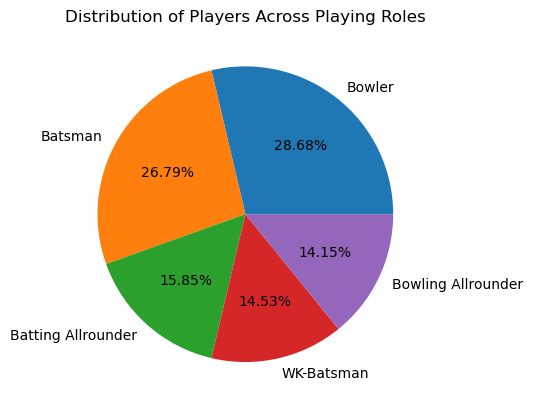

In [115]:
plt.pie(role_count.values,labels = role_count.index,autopct = '%0.2f%%')
plt.title("Distribution of Players Across Playing Roles")
plt.show()

Insight - The uneven distribution of playing roles provides important context for comparing batting performance across roles. Since the number of players varies by role, role-level performance comparisons should consider the representation of each player group.

In [118]:
# How does player participation vary across Test, ODI, T20, and IPL?

In [120]:
format_participation  = {
    'Test' : (cric_data['Test Matches']>0).sum(),
    'ODI' : (cric_data['ODI Matches'] > 0).sum(),
    'T20' : (cric_data['T20 Matches'] >0).sum(),
    'IPL' : (cric_data['Ipl Matches'] >0).sum()
}

In [122]:
format_participation

{'Test': 280, 'ODI': 498, 'T20': 486, 'IPL': 185}

/var/folders/g7/488myycn4wg1190q1gl7y4940000gn/T/ipykernel_67958/1536387134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = format_participation.keys(),


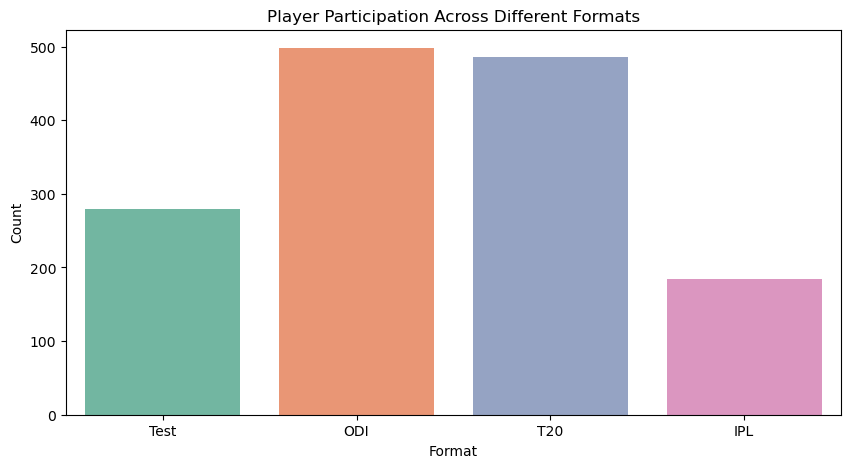

In [124]:
plt.figure(figsize = (10,5))
sns.barplot(x = format_participation.keys(),
           y = format_participation.values(),
           palette = 'Set2')
plt.title("Player Participation Across Different Formats")
plt.xlabel('Format')
plt.ylabel('Count')
plt.show()

Insight - Differences in player participation provide important context for comparing batting performance across formats. Since each format has a different player pool and playing environment, format-specific performance metrics should be interpreted within their respective formats.

In [127]:
# What are the distributions and characteristics of key batting performance metrics such as runs, batting average, and strike rate?

In [129]:
# Distribution of Runs - descrete numerical distribution

Text(0, 0.5, 'Number of Players')

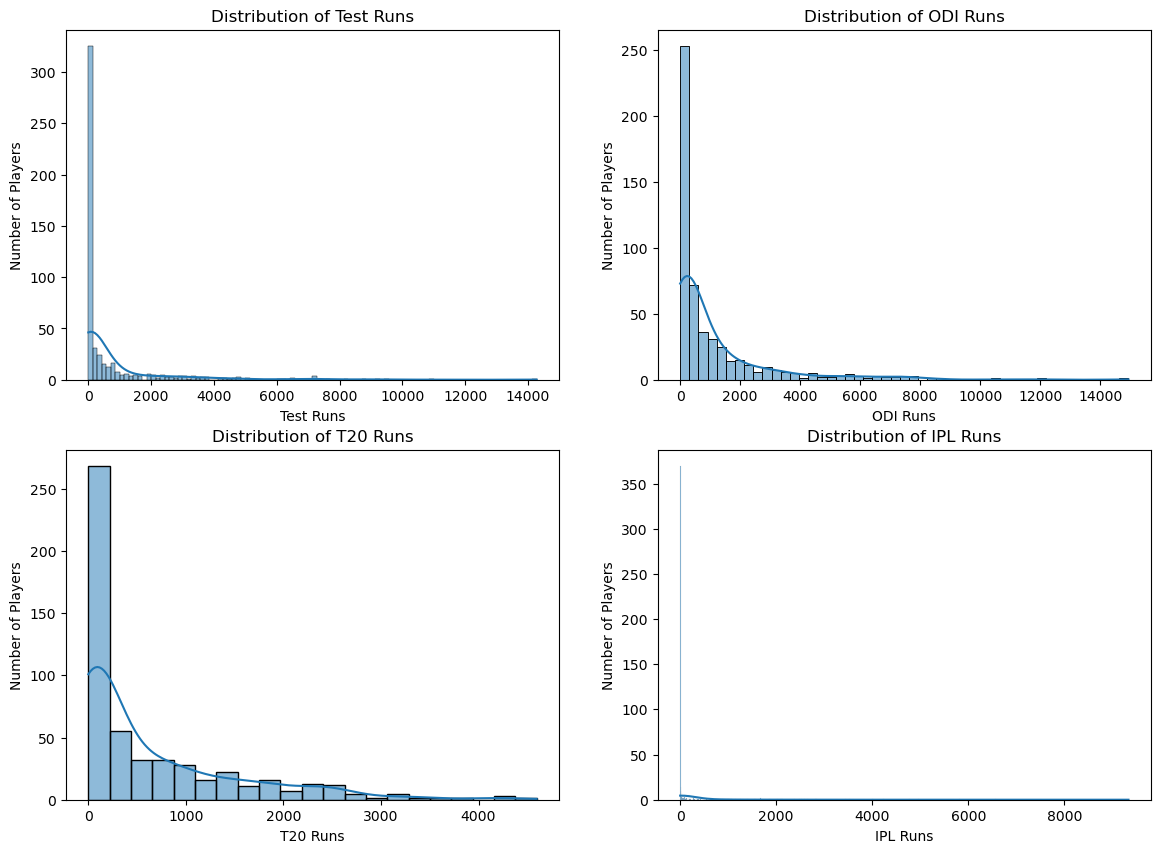

In [131]:
plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.histplot(data = cric_data, x = 'Test Runs',kde = True)
plt.title('Distribution of Test Runs')
plt.xlabel('Test Runs')
plt.ylabel('Number of Players')

plt.subplot(2,2,2)
sns.histplot(data = cric_data, x = 'ODI Runs',kde = True)
plt.title('Distribution of ODI Runs')
plt.xlabel('ODI Runs')
plt.ylabel('Number of Players')

plt.subplot(2,2,3)
sns.histplot(data = cric_data, x = 'T20 Runs',kde = True)
plt.title('Distribution of T20 Runs')
plt.xlabel('T20 Runs')
plt.ylabel('Number of Players')

plt.subplot(2,2,4)
sns.histplot(data = cric_data, x = 'IPL Runs',kde = True)
plt.title('Distribution of IPL Runs')
plt.xlabel('IPL Runs')
plt.ylabel('Number of Players')




Insight -  Longer formats show greater variability in accumulated runs, while shorter formats show relatively more concentrated run distributions

In [133]:
# Distribution of Players Age

In [134]:
cric_data['Age'].value_counts()

Age
34    42
37    40
35    36
31    35
36    34
38    33
32    32
39    31
33    30
28    24
30    21
29    18
40    18
42    17
26    16
43    15
27    13
41    10
44    10
47     7
45     7
23     6
25     6
24     5
46     4
53     4
56     2
49     2
48     2
22     2
50     2
20     2
21     1
67     1
58     1
51     1
Name: count, dtype: int64

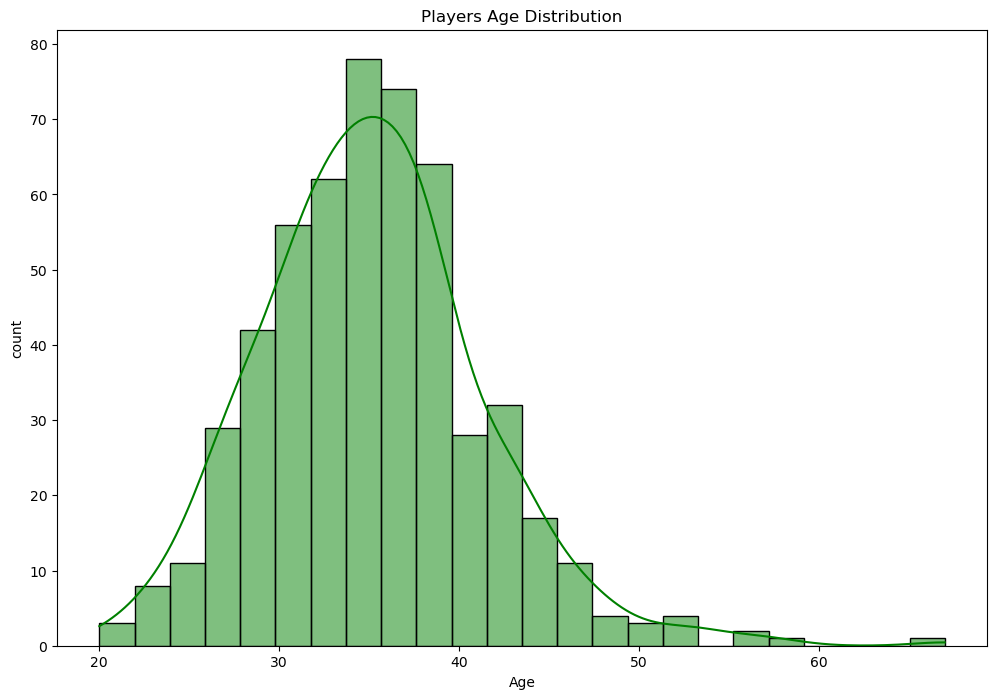

In [135]:
plt.figure(figsize = (12,8))
sns.histplot(data = cric_data,x = 'Age',color = 'Green',kde = True)
plt.title('Players Age Distribution')
plt.xlabel('Age')
plt.ylabel('count')
plt.show()

Insight - This age distribution suggests that the dataset has a strong representation of established and experienced players, which is useful when later analyzing how player age relates to performance, playing role, or format participation.

In [141]:
## Distribution of Economy across different formats

Text(0, 0.5, 'Number of Players')

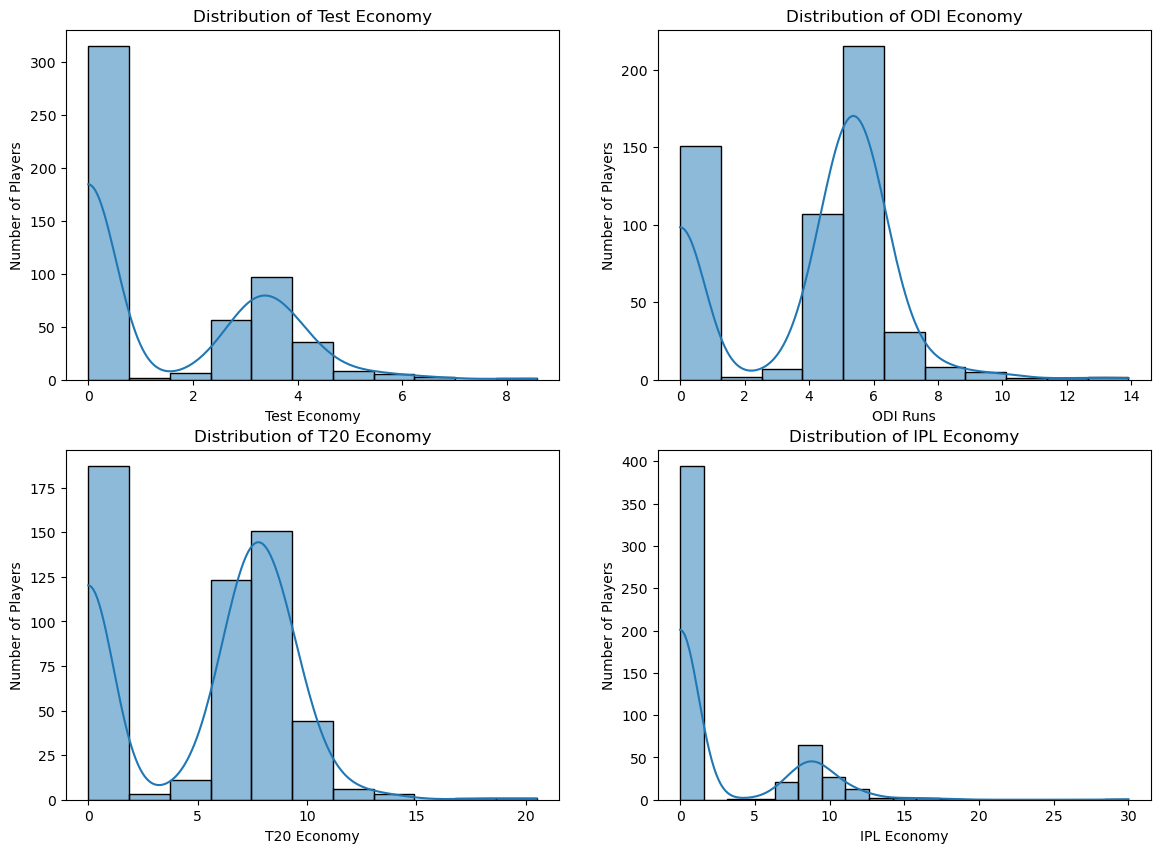

In [143]:
plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.histplot(data = cric_data, x = 'Test Economy',kde = True)
plt.title('Distribution of Test Economy')
plt.xlabel('Test Economy')
plt.ylabel('Number of Players')

plt.subplot(2,2,2)
sns.histplot(data = cric_data, x = 'ODI Economy',kde = True)
plt.title('Distribution of ODI Economy')
plt.xlabel('ODI Runs')
plt.ylabel('Number of Players')

plt.subplot(2,2,3)
sns.histplot(data = cric_data, x = 'T20 Economy',kde = True)
plt.title('Distribution of T20 Economy')
plt.xlabel('T20 Economy')
plt.ylabel('Number of Players')

plt.subplot(2,2,4)
sns.histplot(data = cric_data, x = 'IPL Economy',kde = True)
plt.title('Distribution of IPL Economy')
plt.xlabel('IPL Economy')
plt.ylabel('Number of Players')




Insight - Bowling economy distributions vary across formats, reflecting differences in scoring patterns and match conditions; therefore, economy rate should be interpreted within the context of each cricket format.

In [146]:
# What is the relationship between Age and strike rate across different cricket formats?

In [148]:
for_str = ['Test Strikerate','ODI Strikerate','T20 Strikerate','IPL Strikerate']

In [150]:
for i in range(len(formate)):
    print(cric_data[['Age',formate[i]]].corr())

NameError: name 'formate' is not defined

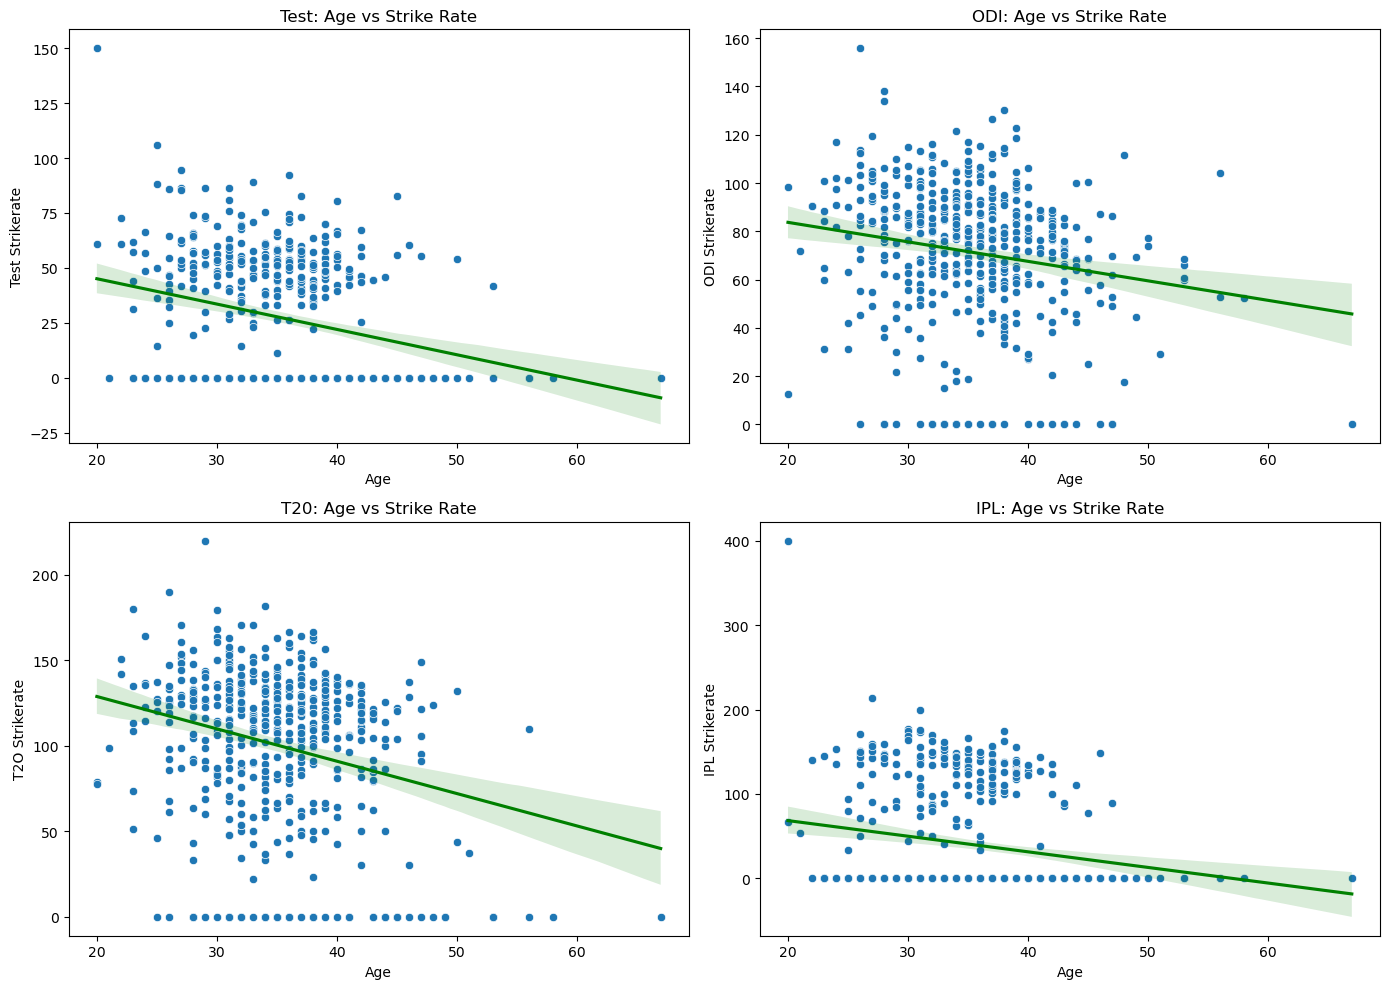

In [151]:
plt.figure(figsize = (14,10))
plt.subplot(2,2,1)
sns.scatterplot(data = cric_data,x = 'Age',y = 'Test Strikerate' )
sns.regplot(data = cric_data,x = 'Age',y = 'Test Strikerate' ,scatter = False,color = 'g')
plt.title("Test: Age vs Strike Rate")
plt.xlabel('Age')
plt.ylabel('Test Strikerate')

plt.subplot(2,2,2)
sns.scatterplot(data = cric_data,x = 'Age',y = 'ODI Strikerate' )
sns.regplot(data = cric_data,x = 'Age',y = 'ODI Strikerate' ,scatter = False,color = 'g')
plt.title("ODI: Age vs Strike Rate")
plt.xlabel('Age')
plt.ylabel('ODI Strikerate')

plt.subplot(2,2,3)
sns.scatterplot(data = cric_data,x = 'Age',y = 'T20 Strikerate' )
sns.regplot(data = cric_data,x = 'Age',y = 'T20 Strikerate' ,scatter = False,color = 'g')
plt.title("T20: Age vs Strike Rate")
plt.xlabel('Age')
plt.ylabel('T2O Strikerate')

plt.subplot(2,2,4)
sns.scatterplot(data = cric_data,x = 'Age',y = 'IPL Strikerate' )
sns.regplot(data = cric_data,x = 'Age',y = 'IPL Strikerate' ,scatter = False,color = 'g')
plt.title("IPL: Age vs Strike Rate")
plt.xlabel('Age')
plt.ylabel('IPL Strikerate')

plt.tight_layout()
plt.show()

Insight - Age shows a weak negative relationship with batting strike rate across all formats, with the strongest association in T20 (-0.255)

In [155]:
# What is the relationship between Average and strike rate across different cricket formats?

In [157]:
for_avg = ['Test Average','ODI Average','T20 Average','IPL Average']
for_str = ['Test Strikerate','ODI Strikerate','T20 Strikerate','IPL Strikerate']

In [159]:
for i in range(len(for_avg)):
    print(cric_data[[for_avg[i],for_str[i]]].corr())

                 Test Average  Test Strikerate
Test Average         1.000000         0.814755
Test Strikerate      0.814755         1.000000
                ODI Average  ODI Strikerate
ODI Average        1.000000        0.622087
ODI Strikerate     0.622087        1.000000
                T20 Average  T20 Strikerate
T20 Average        1.000000        0.743981
T20 Strikerate     0.743981        1.000000
                IPL Average  IPL Strikerate
IPL Average        1.000000        0.859451
IPL Strikerate     0.859451        1.000000


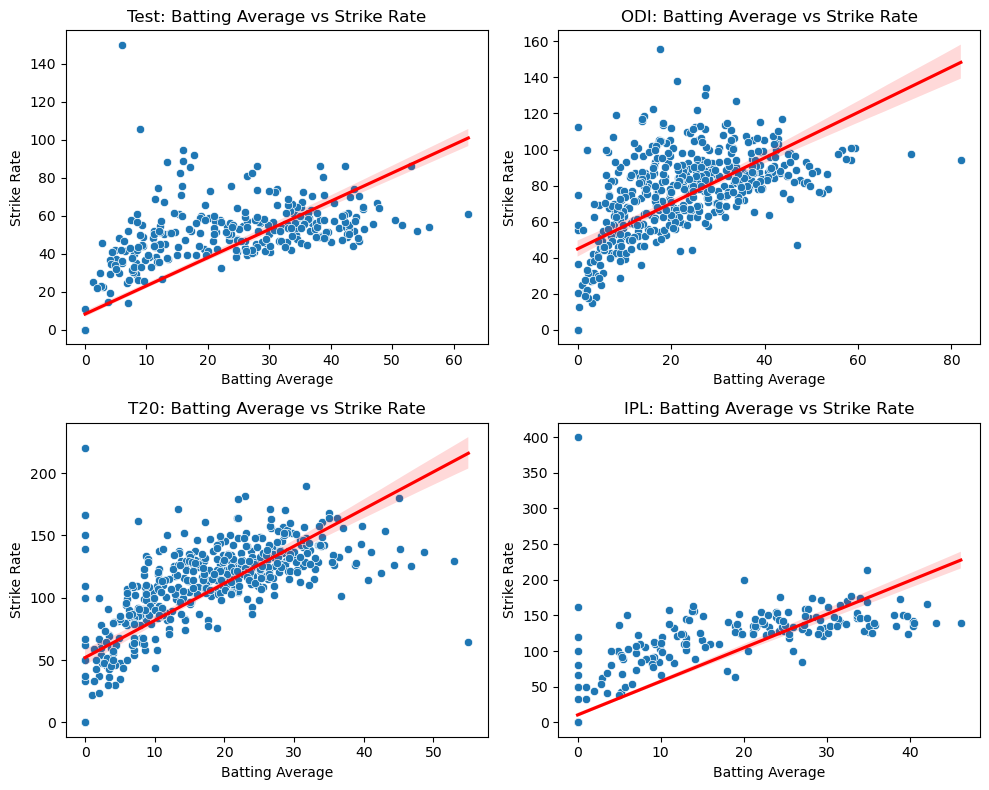

In [161]:
plt.figure(figsize=(10, 8))


plt.subplot(2,2,1)
sns.scatterplot(data = cric_data, x = 'Test Average', y = 'Test Strikerate')
sns.regplot(data = cric_data, x = 'Test Average', y = 'Test Strikerate',scatter=False,color = 'red')
plt.title('Test: Batting Average vs Strike Rate')
plt.xlabel('Batting Average')
plt.ylabel('Strike Rate')

plt.subplot(2,2,2)
sns.scatterplot(data = cric_data, x = 'ODI Average', y = 'ODI Strikerate')
sns.regplot(data = cric_data, x = 'ODI Average', y = 'ODI Strikerate',scatter=False,color = 'red')
plt.title('ODI: Batting Average vs Strike Rate')
plt.xlabel('Batting Average')
plt.ylabel('Strike Rate')

plt.subplot(2,2,3)
sns.scatterplot(data = cric_data, x = 'T20 Average', y = 'T20 Strikerate')
sns.regplot(data = cric_data, x = 'T20 Average', y = 'T20 Strikerate',scatter=False,color = 'red')
plt.title('T20: Batting Average vs Strike Rate')
plt.xlabel('Batting Average')
plt.ylabel('Strike Rate')

plt.subplot(2,2,4)
sns.scatterplot(data = cric_data, x = 'IPL Average', y = 'IPL Strikerate')
sns.regplot(data = cric_data, x = 'IPL Average', y = 'IPL Strikerate',scatter=False,color = 'red')
plt.title('IPL: Batting Average vs Strike Rate')
plt.xlabel('Batting Average')
plt.ylabel('Strike Rate')

plt.tight_layout()
plt.show()

Insight -  batting average and strike rate show a positive association across the formats, but the strength of the relationship differs by format. This highlights that batting performance cannot be fully evaluated using a single metric.

In [164]:
#player batting performance across different roles

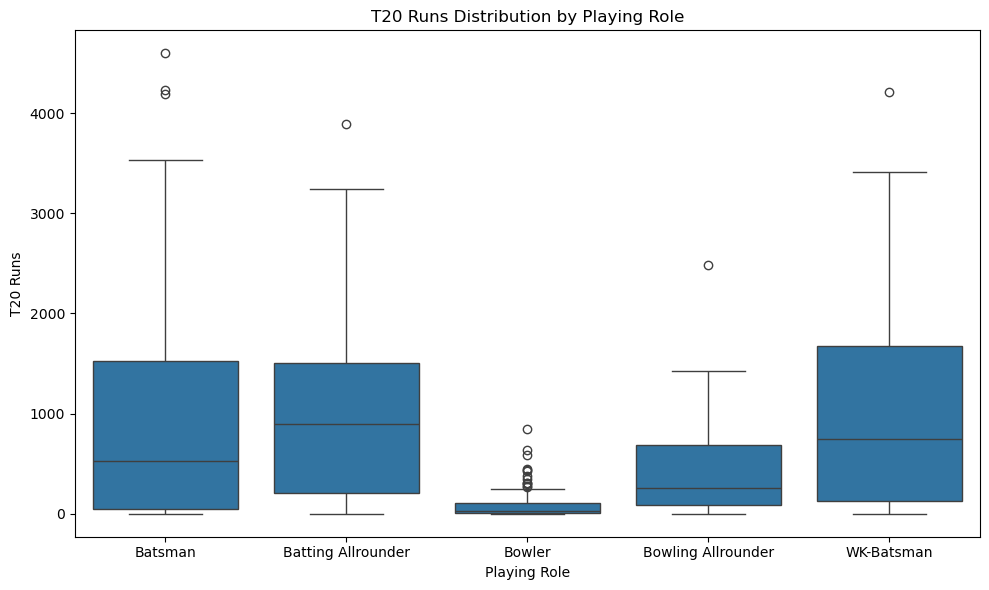

In [166]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=cric_data,x='Role', y='T20 Runs')

plt.title('T20 Runs Distribution by Playing Role')
plt.xlabel('Playing Role')
plt.ylabel('T20 Runs')

plt.tight_layout()
plt.show()

Insight - T20 run distributions vary across playing roles, reflecting differences in batting responsibilities and opportunities; therefore, player performance should be interpreted within the context of their playing role.

In [169]:
# Player perfromance across bowling performance across different roles

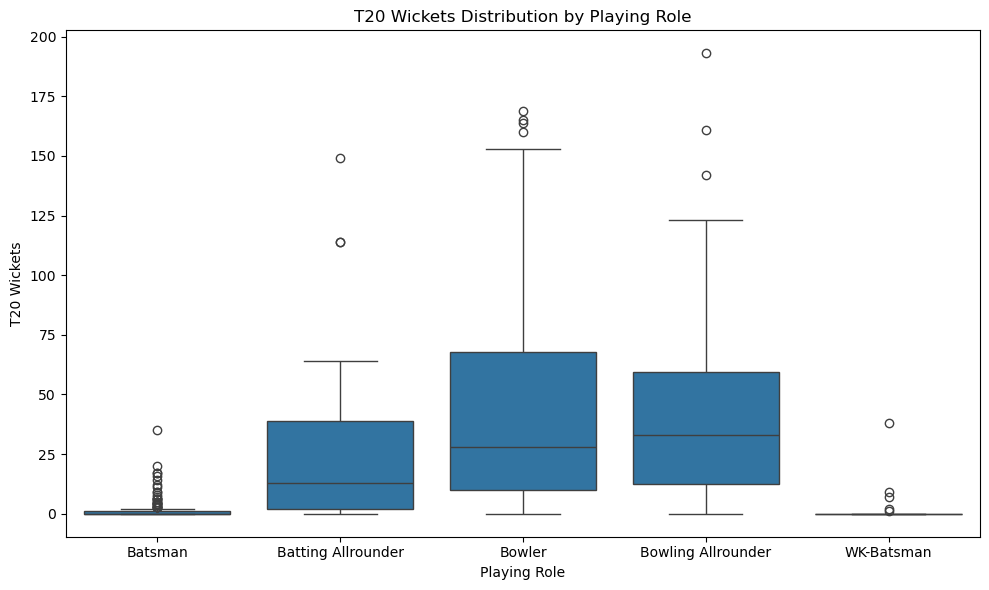

In [171]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=cric_data,x='Role', y='T20 Wickets')

plt.title('T20 Wickets Distribution by Playing Role')
plt.xlabel('Playing Role')
plt.ylabel('T20 Wickets')

plt.tight_layout()
plt.show()

Insight -  T20 wicket distributions differ across playing roles, reflecting differences in bowling responsibilities and opportunities; therefore, wicket-taking performance should be evaluated within the context of player role.

In [174]:
# Batting style distribution across different countries

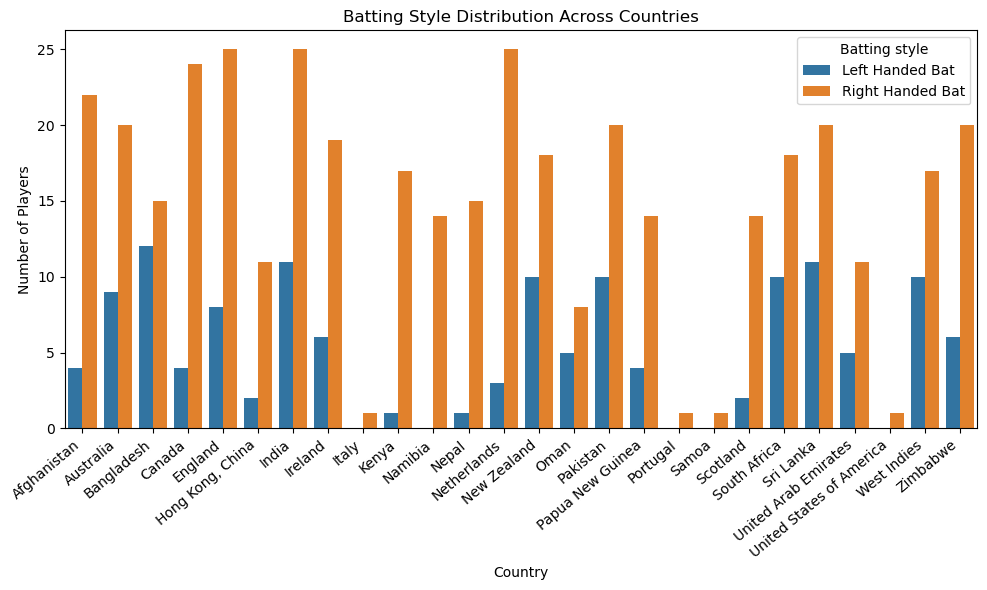

In [176]:
plt.figure(figsize=(10, 6))

sns.countplot(data=cric_data,x='Country',hue='Batting style')

plt.title('Batting Style Distribution Across Countries')
plt.xlabel('Country')
plt.ylabel('Number of Players')
plt.xticks(rotation= 40,ha='right')
plt.tight_layout()
plt.show()

Insight -  Batting-style composition varies across countries, with differences in the proportion of right- and left-handed batters; country-level comparisons should also consider differences in sample size

In [179]:
# Within each bowling style, what proportion of players are right-handed or left-handed batters?

In [181]:
batting_bowling_style= pd.crosstab(index = cric_data_clean['Bowling style'],columns = cric_data_clean['Batting style'],
    normalize='index')

In [183]:
batting_bowling_style

Batting style,Left Handed Bat,Right Handed Bat
Bowling style,,
Left-arm fast,0.250000,0.750000
Left-arm fast-medium,0.500000,0.500000
Left-arm medium,0.000000,1.000000
Left-arm orthodox,0.680000,0.320000
Left-arm wrist-spin,0.250000,0.750000
Right-arm fast,0.151515,0.848485
Right-arm fast-medium,0.120690,0.879310
Right-arm legbreak,0.136364,0.863636
Right-arm medium,0.236842,0.763158


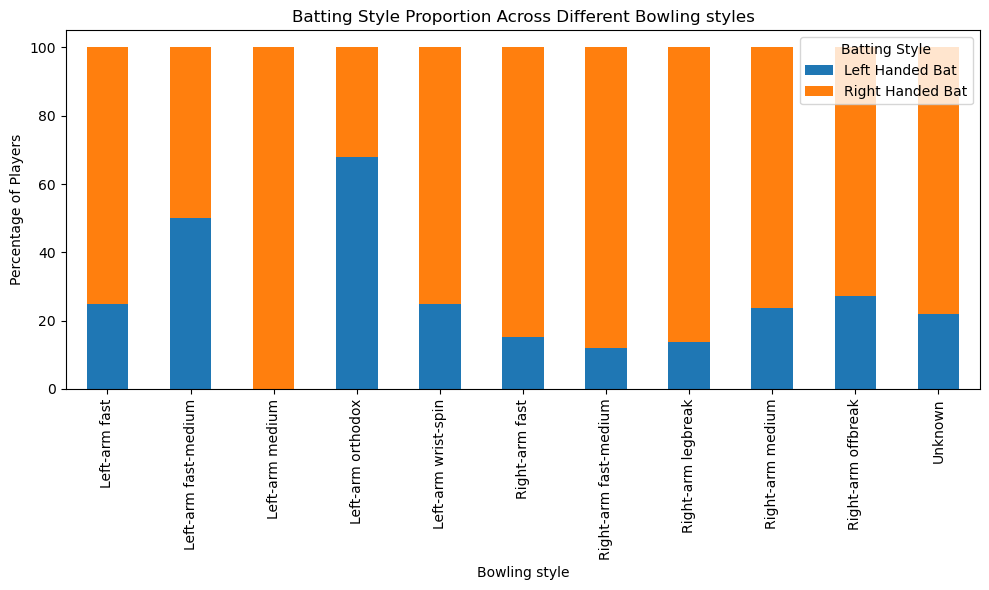

In [185]:

batting_bowling_style = pd.crosstab(index = cric_data['Bowling style'],
                                    columns = cric_data['Batting style'],normalize='index') * 100

batting_bowling_style.plot(kind='bar',stacked=True,figsize = (10,6))
plt.title('Batting Style Proportion Across Different Bowling styles')
plt.xlabel('Bowling style')
plt.ylabel('Percentage of Players')
plt.legend(title='Batting Style')

plt.tight_layout()
plt.show()

Insight -  Batting-style composition varies across bowling styles, with each bowling group showing its own proportion of right- and left-handed batters

In [188]:
# How do multiple batting and bowling performance metrics collectively reveal distinct player-performance patterns?


In [190]:
performance_metrics = ['T20 Runs','T20 Average','T20 Strikerate','T20 Wickets','T20 Economy']

In [192]:
cric_data[performance_metrics].corr()

,T20 Runs,T20 Average,T20 Strikerate,T20 Wickets,T20 Economy
T20 Runs,1.000000,0.667291,0.494109,-0.050278,-0.046984
T20 Average,0.667291,1.000000,0.743981,-0.119127,-0.023046
T20 Strikerate,0.494109,0.743981,1.000000,0.131348,0.232439
T20 Wickets,-0.050278,-0.119127,0.131348,1.000000,0.397921
T20 Economy,-0.046984,-0.023046,0.232439,0.397921,1.000000


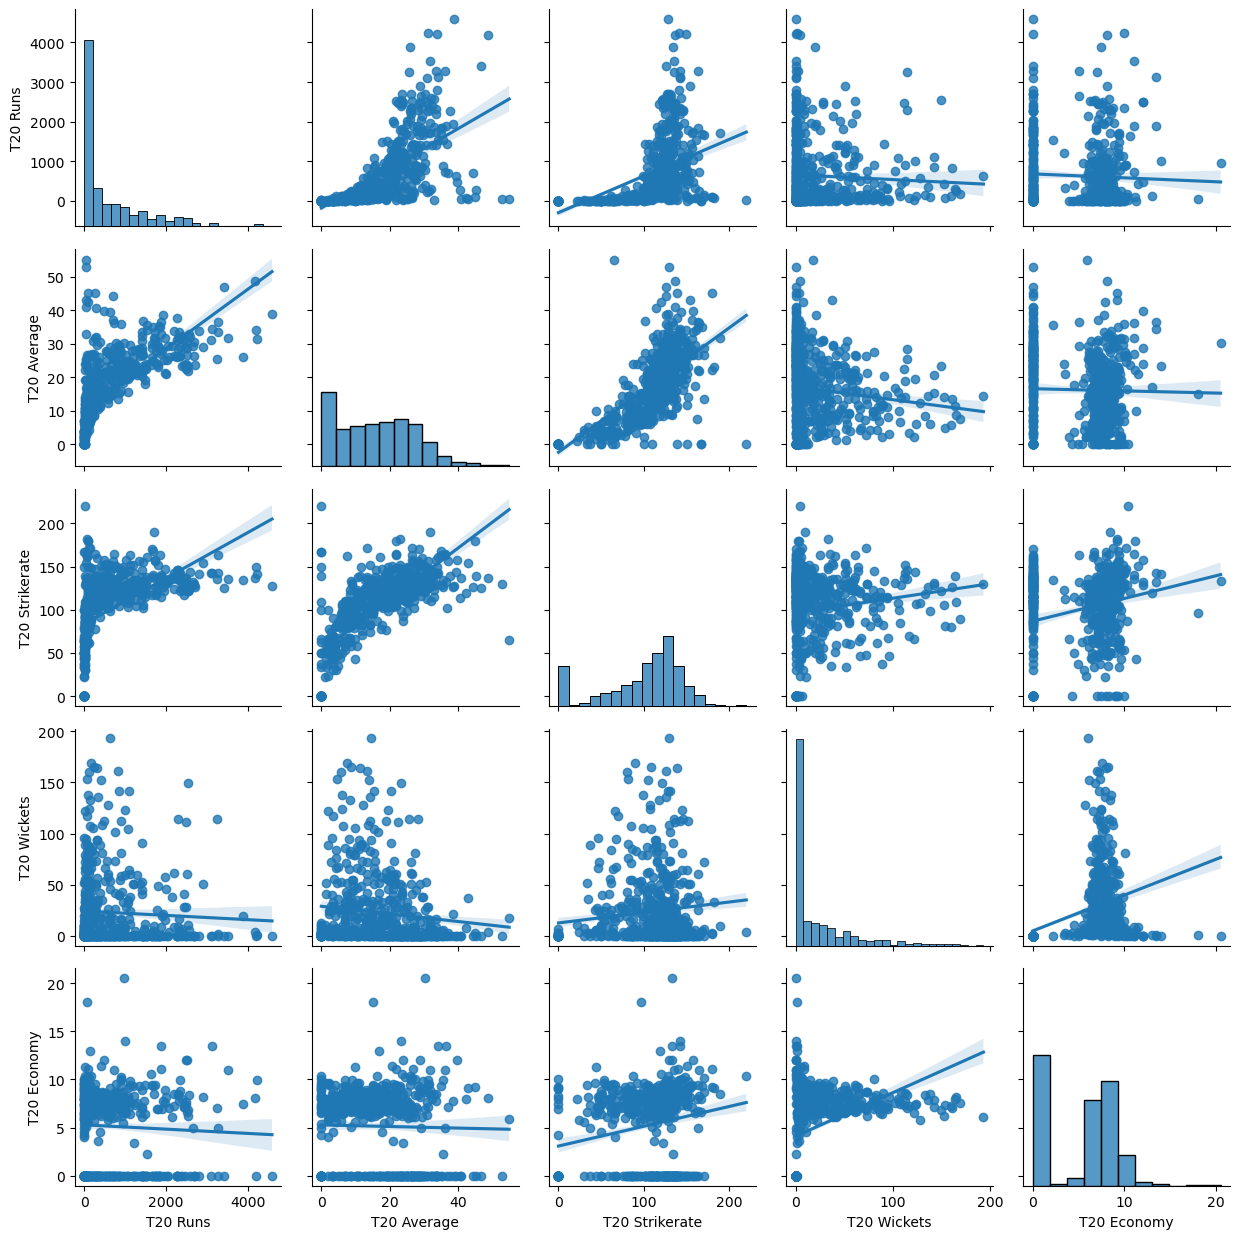

In [194]:
sns.pairplot(cric_data[performance_metrics],kind='reg',diag_kind='hist')

plt.tight_layout()
plt.show()


Insight - T20 batting metrics show stronger relationships with each other than with bowling metrics, while wickets and economy capture a different dimension of performance. Considering multiple metrics together provides a more complete view of distinct player-performance patterns.

In [196]:
# How does multiple batting performance metrices collectively reveal distinct player performance

In [197]:
batting_metrics = [
    'T20 Runs',
    'T20 Strikerate',
    'T20 50s',
    'T20 100s'
]

In [201]:
cric_data[batting_metrics].corr()

,T20 Runs,T20 Strikerate,T20 50s,T20 100s
T20 Runs,1.000000,0.494109,0.935318,0.601918
T20 Strikerate,0.494109,1.000000,0.394666,0.298438
T20 50s,0.935318,0.394666,1.000000,0.607395
T20 100s,0.601918,0.298438,0.607395,1.000000


<Figure size 1800x800 with 0 Axes>

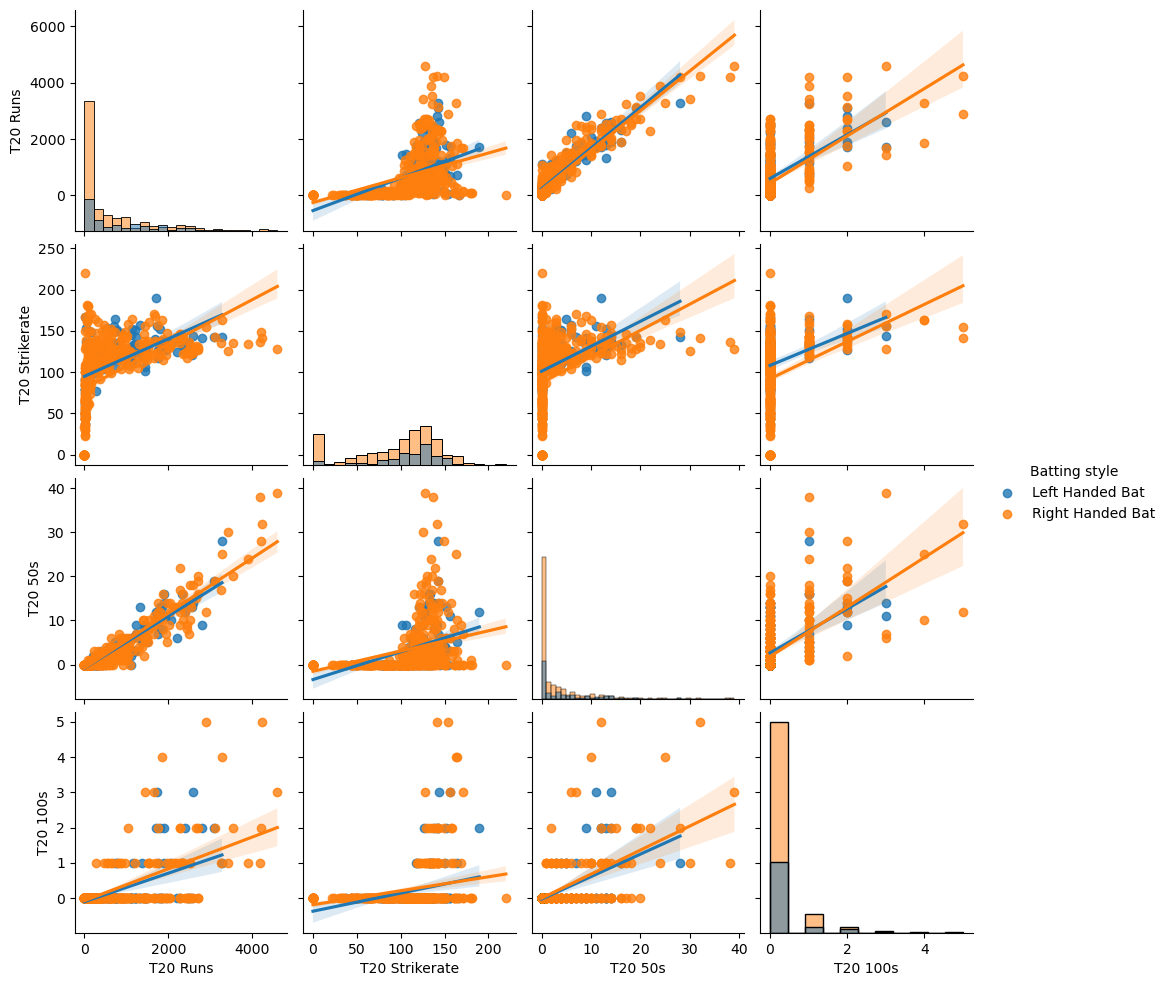

In [203]:

plt.figure(figsize = (18,8))
sns.pairplot(
    cric_data[batting_metrics+['Batting style']],
    kind='reg',
    hue = 'Batting style',
    diag_kind='hist',
)

plt.show()

Insight - Combining T20 runs, strike rate, 50s, and 100s provides a broader view of batting performance and helps identify distinct performance patterns across right- and left-handed batters.

In [205]:
# How does multiple bowling performance metrices collectively reveal distinct player performance

In [208]:
bowling_metrics = [
    'T20 Wickets',
    'T20 Economy',
    'T20 Maidens']

In [210]:
cric_data[bowling_metrics].corr()

,T20 Wickets,T20 Economy,T20 Maidens
T20 Wickets,1.000000,0.397921,0.662097
T20 Economy,0.397921,1.000000,0.232025
T20 Maidens,0.662097,0.232025,1.000000


<Axes: >

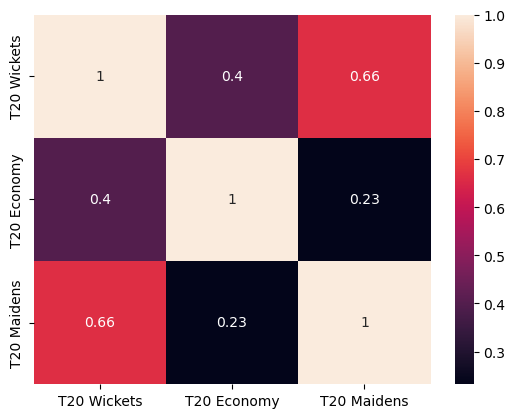

In [212]:
sns.heatmap(cric_data[bowling_metrics].corr(),annot = True)

Insight - T20 wickets and maidens show the strongest association, while economy has weaker relationships with the other metrics, indicating that multiple bowling metrics are needed to capture different dimensions of player performance.

#### Recommendations

* Evaluate player performance within the context of the cricket format.

Since player participation and run distributions vary considerably across Test, ODI, T20, and IPL, performance metrics should be compared within the same format rather than directly comparing raw totals across formats.

* Consider player role when evaluating performance.

Batting and bowling responsibilities differ across playing roles. Therefore, metrics such as runs and wickets should be interpreted alongside the player's role instead of using a single performance metric to compare all players.

* Use multiple performance metrics for player evaluation.

Runs, batting average, strike rate, wickets, economy, and other metrics represent different dimensions of performance. A combination of metrics provides a more comprehensive view than relying on a single statistic.

* Consider player age as a contextual factor.

The analysis showed a weak negative relationship between age and batting strike rate across formats. Age can therefore be considered as one contextual factor when studying batting performance, but it should not be treated as a strong standalone predictor.

* Consider sample size when making country-level comparisons.

Player representation varies substantially across countries. Comparisons involving countries with very few players should therefore be interpreted cautiously.

### Conclusion


The analysis identified meaningful patterns in player performance across formats, roles, countries, age, and playing styles. The findings show that player performance varies by context, and no single metric is sufficient to evaluate a player. Using multiple performance metrics with proper context provides a more comprehensive understanding of cricket player performance.